In [1]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install lightgbm
#%pip install shap
#%pip install lime

In [2]:
import pandas as pd #Importamos pandas para el manejo de dataframes y series temporales
import numpy as np #Importamos numpy para el manejo de arrays y operaciones matemáticas
import matplotlib.pyplot as plt #Importamos matplotlib para la visualización de datos       
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit #Importamos GridSearchCV para la búsqueda de hiperparámetros y TimeSeriesSplit para la validación cruzada en series temporales
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer #Importamos mean_absolute_error, mean_squared_error y r2_score para la evaluación del rendimiento del modelo de machine learning
import joblib #Importamos joblib para guardar y cargar modelos de machine learning entrenados
import lightgbm as lgb #Importamos lightgbm para la construcción de modelos de machine learning basados en gradient boosting
from sklearn.isotonic import IsotonicRegression #Importamos IsotonicRegression para realizar regresión isotónica, que es una técnica de ajuste de curvas monotónicas
import shap
import lime

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../../dataset_ml.csv') 
print(df.columns)

df.head()
df.drop(columns=['precio'], inplace=True) #Eliminamos la columna 'Date' ya que no es una característica numérica y no aporta información relevante para el modelo. Además, eliminamos la columna 'target' ya que es la variable que queremos predecir.

Index(['oro_return', 'precio', 'inflacion_usa', 'volatilidad_6m', 'lag_3',
       'tipos_ecb', 'eurusd', 'activo_return', 'desempleo', 'sp500_return',
       'vix', 'tipos_fed', 'curva10Y2Y', 'target', 'tipos_fed_lag1',
       'tipos_fed_lag3', 'tipos_fed_lag6', 'inflacion_usa_lag1',
       'inflacion_usa_lag3', 'inflacion_usa_lag6', 'vix_lag1', 'vix_lag2',
       'vix_lag3', 'desempleo_lag1', 'desempleo_lag3', 'curva10Y2Y_lag1',
       'curva10Y2Y_lag3'],
      dtype='object')


In [4]:
X = df.drop(columns=['target']) #Separamos las características (X) de la variable objetivo (Y) para preparar los datos para el entrenamiento del modelo de machine learning.
Y = df['target']

In [5]:
def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    '''Función para dividir un dataframe en conjuntos de entrenamiento, validación y prueba.
    Parámetros:
    dataframe: DataFrame a dividir
    tr_size: Proporción de datos para el conjunto de entrenamiento (default=0.8)
    vl_size: Proporción de datos para el conjunto de validación (default=0.1)
    ts_size: Proporción de datos para el conjunto de prueba (default=0.1)
    Retorna:
    train: DataFrame de entrenamiento
    val: DataFrame de validación
    test: DataFrame de prueba
    '''
    N = dataframe.shape[0] # Número total de datos
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = int(ts_size*N)    # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain] # Conjunto de entrenamiento
    val = dataframe[Ntrain:Ntrain+Nval] # Conjunto de validación
    test = dataframe[Ntrain+Nval:] # Conjunto de prueba

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df) # Dividimos el dataframe en conjuntos de entrenamiento, validación y prueba utilizando la función division_conjuntos.

X_train = tr.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de entrenamiento, eliminando la columna 'target' que es la variable que queremos predecir.
y_train = tr['target']

X_val = vl.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de validación, eliminando la columna 'target' que es la variable que queremos predecir.
y_val = vl['target']

X_test = ts.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de prueba, eliminando la columna 'target' que es la variable que queremos predecir.
y_test = ts['target']

print(f'Entrenamiento: {X_train.shape}')
print(f'Validación: {X_val.shape}')
print(f'Prueba: {X_test.shape}')

Entrenamiento: (212, 25)
Validación: (26, 25)
Prueba: (27, 25)


In [6]:
def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    valid = true_dir != 0
    if valid.sum() == 0:
        return 0
    return np.mean(true_dir[valid] == pred_dir[valid])

# Creamos el scorer para GridSearch
da_scorer = make_scorer(directional_accuracy, greater_is_better=True)

In [7]:

param_grid_lgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 15],
    'subsample': [0.7, 0.8, 0.9]
} #Definimos una cuadrícula de hiperparámetros para el modelo de LightGBM,

ts_cv = TimeSeriesSplit(n_splits=3) #Definimos una estrategia de validación cruzada para series temporales utilizando TimeSeriesSplit, que divide los datos en conjuntos de entrenamiento y validación respetando el orden temporal de los datos.

# Inicializar el modelo
lgb_model = lgb.LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=-1  # Para que no imprima mensajes de entrenamiento
)

grid_search_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid_lgb,
    cv=ts_cv,
    scoring=da_scorer,
    verbose=1,
    n_jobs=-1
)  # Configuramos la búsqueda de hiperparámetros utilizando GridSearchCV, especificando el modelo, la cuadrícula de hiperparámetros, la estrategia de validación cruzada, la métrica de evaluación, y habilitando la salida detallada y el uso de múltiples núcleos para acelerar el proceso.

# Ajustar la búsqueda
grid_search_lgb.fit(X_train, y_train) #Ejecutamos la búsqueda de hiperparámetros ajustando el modelo a los datos de entrenamiento utilizando la configuración definida en GridSearchCV.


print(f"Mejores hiperparámetros: {grid_search_lgb.best_params_}")
print(f"Mejor MAE: {-grid_search_lgb.best_score_:.4f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits


Mejores hiperparámetros: {'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.7}
Mejor MAE: -0.6164


In [8]:
best_lgb = lgb.LGBMRegressor(**grid_search_lgb.best_params_, random_state=42, n_jobs=-1) #Creamos un nuevo modelo de LightGBM Regressor utilizando los mejores hiperparámetros encontrados en la búsqueda.
best_lgb.fit(X_train, y_train) #Entrenamos el modelo de LightGBM Regressor con los mejores hiperparámetros utilizando los datos de entrenamiento.

y_pred_val = best_lgb.predict(X_val) #Realizamos predicciones utilizando el modelo entrenado en el conjunto de validación para evaluar su rendimiento antes de probarlo en el conjunto de prueba.
y_pred_test = best_lgb.predict(X_test)

# Métricas de validación
mae_val = mean_absolute_error(y_val, y_pred_val) #Calculamos el error absoluto medio (MAE) entre las predicciones del modelo y los valores reales en el conjunto de validación para evaluar la precisión del modelo.
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val)) #Calculamos la raíz del error cuadrático medio (RMSE) entre las predicciones del modelo y los valores reales en el conjunto de validación para evaluar la precisión del modelo, penalizando más los errores grandes.
r2_val = r2_score(y_val, y_pred_val)
da_val = directional_accuracy(y_val, y_pred_val)

print(f"MAE: {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"R²: {r2_val:.4f}")
print(f"Directional Accuracy: {da_val:.4f}")

MAE: 0.0829
RMSE: 0.0965
R²: -0.3756
Directional Accuracy: 0.3462


MAE: 0.0744
RMSE: 0.0951
R²: -0.3361
Directional Accuracy: 0.5769

In [9]:
# Evaluación en el conjunto de prueba
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
da_test = directional_accuracy(y_test, y_pred_test)

print(f"MAE: {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²: {r2_test:.4f}")
print(f"Directional Accuracy: {da_test:.4f}")

MAE: 0.0616
RMSE: 0.0760
R²: -0.7227
Directional Accuracy: 0.6296


MAE: 0.0385
RMSE: 0.0495
R²: 0.2688
Directional Accuracy: 0.7778

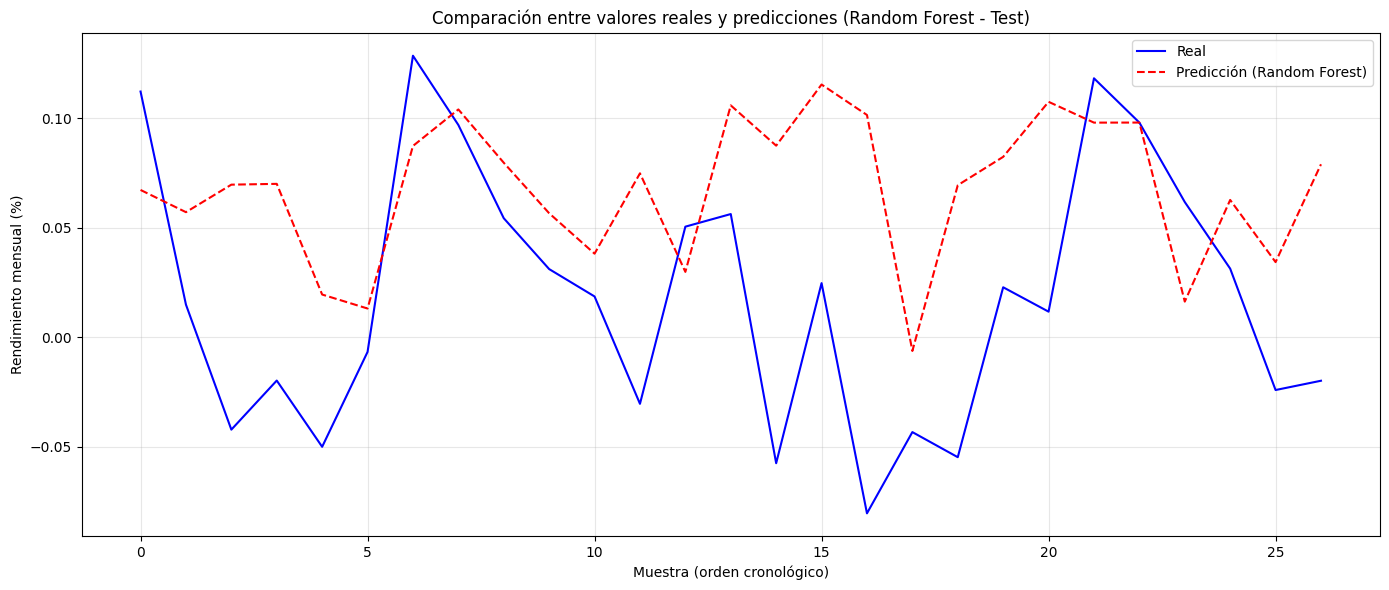

In [10]:
plt.figure(figsize=(14, 6))

# Ordenar por índice (asegurar orden cronológico)
indices = range(len(y_test))

plt.plot(indices, y_test.values, label='Real', color='blue', linewidth=1.5)
plt.plot(indices, y_pred_test, label='Predicción (Random Forest)', color='red', linestyle='--', linewidth=1.5)

plt.title('Comparación entre valores reales y predicciones (Random Forest - Test)')
plt.xlabel('Muestra (orden cronológico)')
plt.ylabel('Rendimiento mensual (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [11]:
def backtesting_rf(dataframe, window_train=180, test_size=12, step=12, best_params=None):
    """
    Realiza backtesting con ventana deslizante para Random Forest.
    
    Parámetros:
    -----------
    dataframe : DataFrame
        Dataset completo ordenado cronológicamente
    window_train : int
        Tamaño de la ventana de entrenamiento (meses)
    test_size : int
        Tamaño de la ventana de prueba (meses)
    step : int
        Número de meses que se desplaza la ventana en cada iteración
    best_params : dict
        Mejores hiperparámetros encontrados en la búsqueda previa
        
    Retorna:
    --------
    resultados : DataFrame
        DataFrame con las métricas de cada iteración
    media_metricas : dict
        Diccionario con las métricas promedio
    """
    
    resultados = []
    
    if best_params is None:
        best_params = {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_split': 10,
            'min_samples_leaf': 4,
            'random_state': 42,
            'n_jobs': -1
        } # Si no se proporcionan mejores hiperparámetros, se usan valores por defecto
    
    # Calcular número total de iteraciones
    n_iterations = (len(dataframe) - window_train - test_size) // step + 1 # Calculamos el número total de iteraciones que se realizarán en el backtesting, teniendo en cuenta el tamaño de la ventana de entrenamiento, el tamaño de la ventana de prueba y el paso de desplazamiento.
    
    for i, start in enumerate(range(0, len(dataframe) - window_train - test_size, step)): # Iteramos sobre el rango de índices para crear las ventanas de entrenamiento y prueba, desplazando la ventana en cada iteración según el paso definido.
        
        train_end = start + window_train
        test_end = train_end + test_size
        
        # Obtenemos los datos de entrenamiento y prueba
        train = dataframe.iloc[start:train_end]
        test = dataframe.iloc[train_end:test_end]
        
        # Separamos características (X) y variable objetivo (y)
        X_train = train.drop(columns=['target'])
        y_train = train['target']
        
        X_test = test.drop(columns=['target'])
        y_test = test['target']
        
        # Creamos y entrenamos el modelo con los mejores hiperparámetros
        # Creamos y entrenamos el modelo con los mejores hiperparámetros
        lgb_model = lgb.LGBMRegressor(**best_params, verbose=-1)
        lgb_model.fit(X_train, y_train)

        # Realizamos predicciones
        y_pred = lgb_model.predict(X_test)
        
        # Calculamos métricas
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        if isinstance(dataframe.index, pd.RangeIndex): # Información de las fechas (si el índice es numérico, mostrar rangos)
            periodo_train = f"[{start}:{train_end-1}]"
            periodo_test = f"[{train_end}:{test_end-1}]"
        else: # Información de las fechas (si el índice es de tipo fecha, mostrar rangos de fechas)
            periodo_train = f"{train.index[0]} - {train.index[-1]}"
            periodo_test = f"{test.index[0]} - {test.index[-1]}"
        
        resultados.append({
            'iteracion': i + 1,
            'train_inicio': start,
            'train_fin': train_end - 1,
            'test_inicio': train_end,
            'test_fin': test_end - 1,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Da': directional_accuracy(y_test, y_pred)
        }) # Guardamos los resultados de cada iteración en una lista de diccionarios, donde cada diccionario contiene la información de la iteración, los índices de las ventanas de entrenamiento y prueba, y las métricas calculadas (MAE, RMSE, R²).
            
    df_resultados = pd.DataFrame(resultados) # Convertimos la lista de resultados a un DataFrame para facilitar el análisis y la visualización de las métricas obtenidas en cada iteración del backtesting.
    
    media_metricas = {
        'MAE_mean': df_resultados['MAE'].mean(),
        'MAE_std': df_resultados['MAE'].std(),
        'RMSE_mean': df_resultados['RMSE'].mean(),
        'RMSE_std': df_resultados['RMSE'].std(),
        'R2_mean': df_resultados['R2'].mean(),
        'R2_std': df_resultados['R2'].std(),
        'Da_mean': df_resultados['Da'].mean(),
        'Da_std': df_resultados['Da'].std()    
    } # Calculamos las métricas promedio y su desviación estándar para cada métrica (MAE, RMSE, R²) a partir de los resultados obtenidos en cada iteración del backtesting.
    
    
    print(f"MAE medio: {media_metricas['MAE_mean']:.4f} (±{media_metricas['MAE_std']:.4f})")
    print(f"RMSE medio: {media_metricas['RMSE_mean']:.4f} (±{media_metricas['RMSE_std']:.4f})")
    print(f"R² medio: {media_metricas['R2_mean']:.4f} (±{media_metricas['R2_std']:.4f})")
    print(f"Directional Accuracy media: {media_metricas['Da_mean']:.4f} (±{media_metricas['Da_std']:.4f})")
    
    return df_resultados, media_metricas

In [12]:
best_params_rf = grid_search_lgb.best_params_
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

# Ejecutamos backtesting
resultados_backtest, metricas_backtest = backtesting_rf(
    dataframe=df,
    window_train=220,  # 200 meses de entrenamiento (~16.7 años)
    test_size=12,      # 24 meses de prueba (~2 años)   probar con 20
    step=18,           # Desplazar la ventana 12 meses cada iteración
    best_params=best_params_rf
)

MAE medio: 0.0706 (±0.0487)
RMSE medio: 0.0845 (±0.0525)
R² medio: -0.1036 (±0.6274)
Directional Accuracy media: 0.5833 (±0.2357)


MAE medio: 0.0595 (±0.0172)
RMSE medio: 0.0725 (±0.0200)
R² medio: -0.0544 (±0.0861)
Directional Accuracy media: 0.5769 (±0.1088)

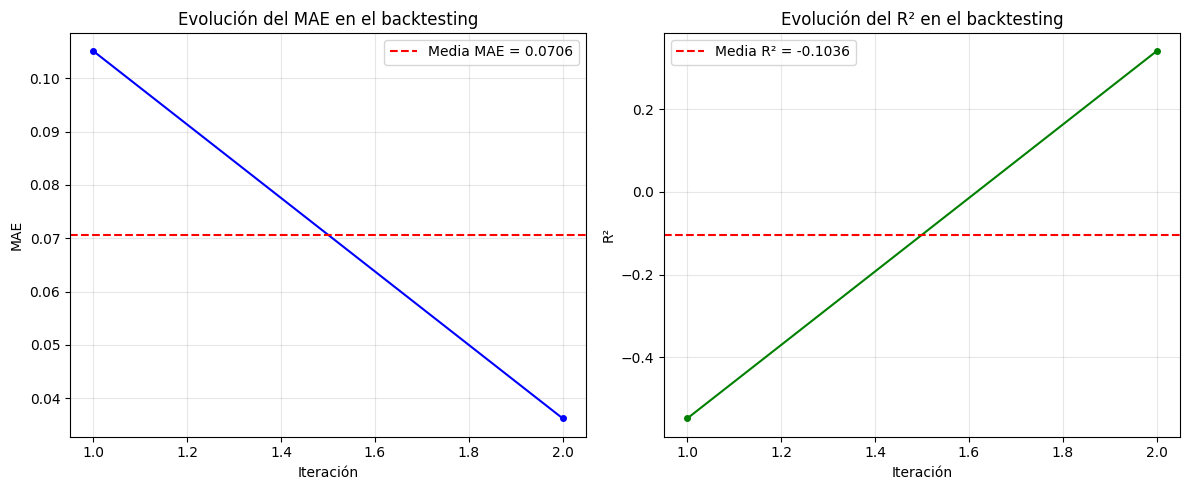

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['MAE'], 'o-', color='blue', markersize=4)
plt.axhline(y=metricas_backtest['MAE_mean'], color='red', linestyle='--', label=f'Media MAE = {metricas_backtest["MAE_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('MAE')
plt.title('Evolución del MAE en el backtesting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['R2'], 'o-', color='green', markersize=4)
plt.axhline(y=metricas_backtest['R2_mean'], color='red', linestyle='--', label=f'Media R² = {metricas_backtest["R2_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('R²')
plt.title('Evolución del R² en el backtesting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# Tomamos una muestra representativa del entrenamiento (100 muestras)
X_train_sample = X_train.sample(n=min(100, len(X_train)), random_state=42)

# TreeExplainer funciona también para LightGBM
print("Creando explainer para LightGBM...")
explainer_lgb = shap.TreeExplainer(best_lgb)

# Calcular los valores SHAP para el conjunto de prueba
print("Calculando valores SHAP para LightGBM...")
shap_values_lgb = explainer_lgb.shap_values(X_test)

Creando explainer para LightGBM...
Calculando valores SHAP para LightGBM...


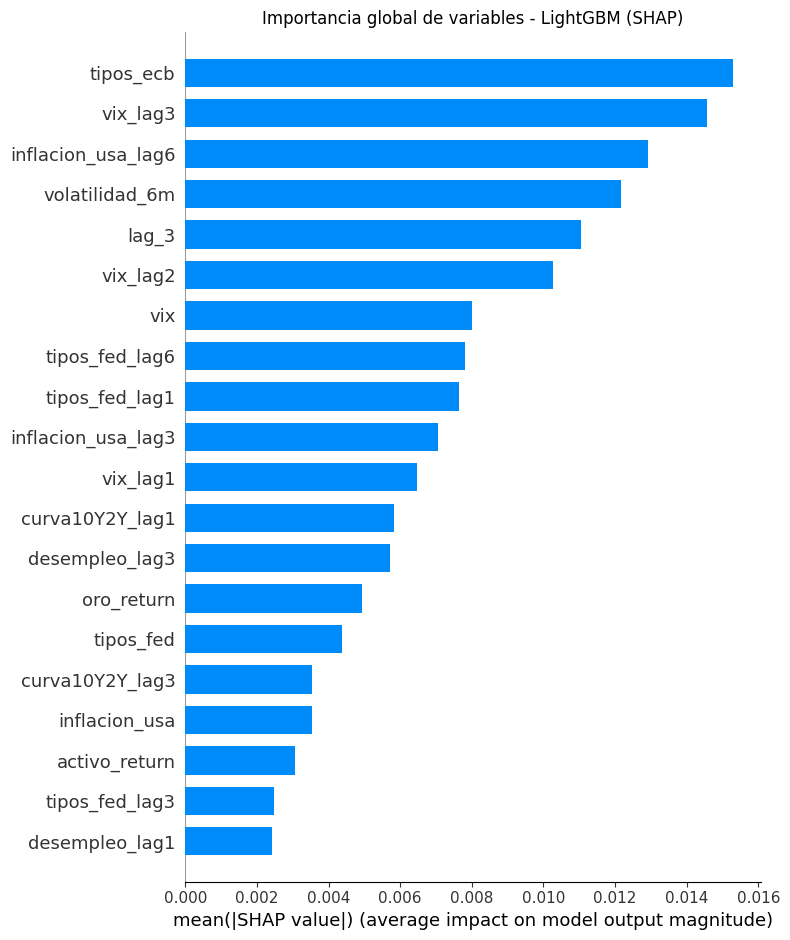

In [15]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_lgb, X_test, plot_type="bar", show=False)
plt.title("Importancia global de variables - LightGBM (SHAP)")
plt.tight_layout()
plt.show()

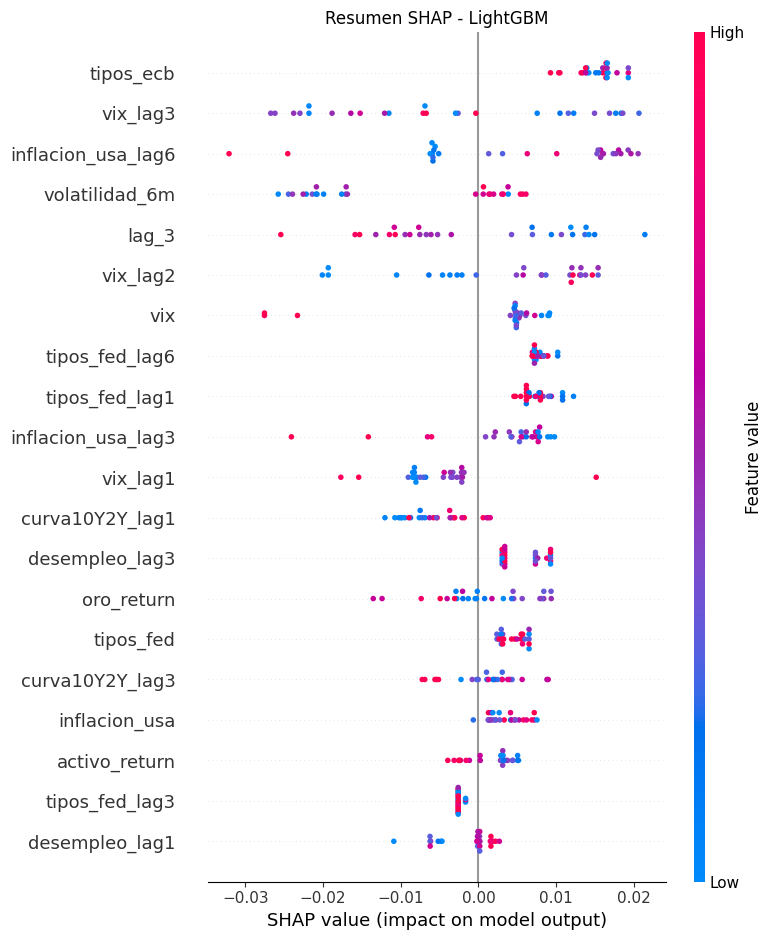

In [16]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_lgb, X_test, show=False)
plt.title("Resumen SHAP - LightGBM")
plt.tight_layout()
plt.show()

In [17]:
mean_abs_shap_lgb = np.abs(shap_values_lgb).mean(axis=0)
feature_names = X_test.columns

importance_df_lgb = pd.DataFrame({
    'Variable': feature_names,
    'Importancia_SHAP': mean_abs_shap_lgb
}).sort_values('Importancia_SHAP', ascending=False)

print("\n=== TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) - LIGHTGBM ===")
print(importance_df_lgb.head(10).to_string(index=False))



=== TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) - LIGHTGBM ===
          Variable  Importancia_SHAP
         tipos_ecb          0.015301
          vix_lag3          0.014555
inflacion_usa_lag6          0.012912
    volatilidad_6m          0.012177
             lag_3          0.011045
          vix_lag2          0.010260
               vix          0.007992
    tipos_fed_lag6          0.007802
    tipos_fed_lag1          0.007630
inflacion_usa_lag3          0.007056


Variable más importante: tipos_ecb


<Figure size 1000x600 with 0 Axes>

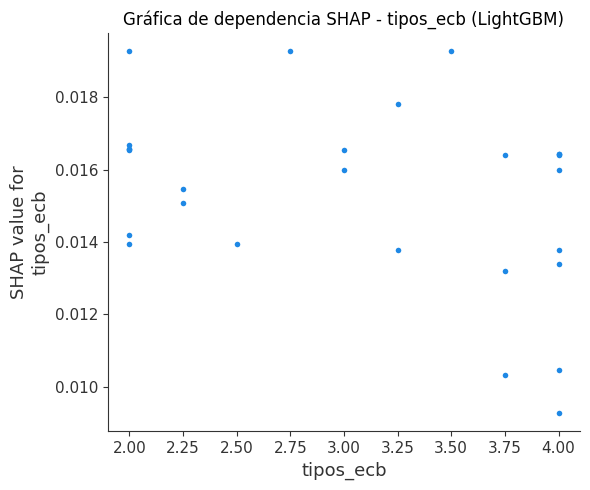

In [18]:
most_important_feature_lgb = importance_df_lgb.iloc[0]['Variable']
most_important_idx_lgb = X_test.columns.get_loc(most_important_feature_lgb)

print(f"Variable más importante: {most_important_feature_lgb}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(most_important_idx_lgb, shap_values_lgb, X_test, 
                     interaction_index=None, show=False)
plt.title(f"Gráfica de dependencia SHAP - {most_important_feature_lgb} (LightGBM)")
plt.tight_layout()
plt.show()

Forma de shap_values_for_plot: (25,)


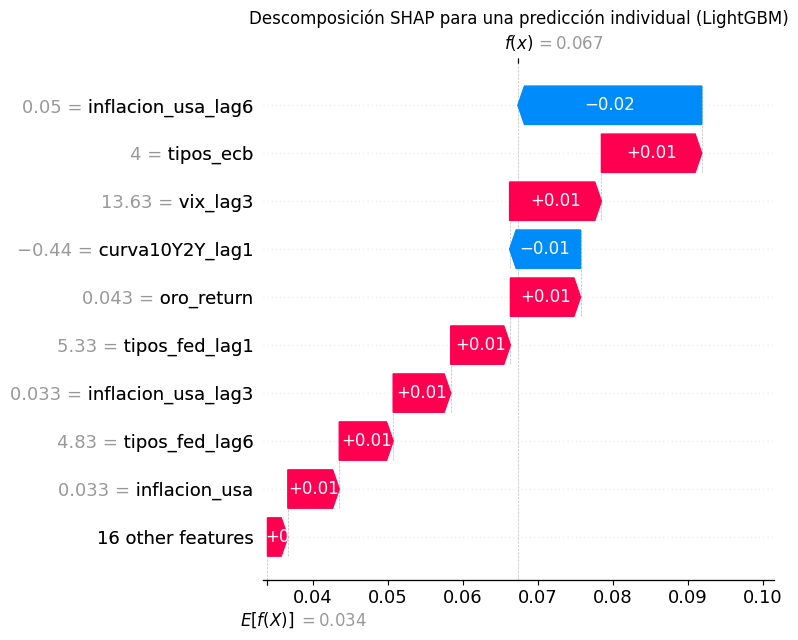

In [19]:
# Elegimos una muestra del conjunto de prueba (la primera)
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]

# Calcular valores SHAP para la muestra
shap_values_sample_lgb = explainer_lgb.shap_values(sample)

# Obtener el valor base como escalar
expected_value_lgb = explainer_lgb.expected_value
if isinstance(expected_value_lgb, np.ndarray):
    expected_value_scalar_lgb = expected_value_lgb[0]
else:
    expected_value_scalar_lgb = expected_value_lgb

# Aplanar el array si es necesario
if len(shap_values_sample_lgb.shape) > 1:
    shap_values_for_plot_lgb = shap_values_sample_lgb.flatten()
else:
    shap_values_for_plot_lgb = shap_values_sample_lgb

print(f"Forma de shap_values_for_plot: {shap_values_for_plot_lgb.shape}")

# Crear el objeto Explanation
explanation_lgb = shap.Explanation(
    values=shap_values_for_plot_lgb,
    base_values=expected_value_scalar_lgb,
    data=sample.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

# Generar el waterfall plot
plt.figure(figsize=(12, 6))
shap.waterfall_plot(explanation_lgb, show=False)
plt.title(f"Descomposición SHAP para una predicción individual (LightGBM)")
plt.tight_layout()
plt.show()

<Figure size 1400x400 with 0 Axes>

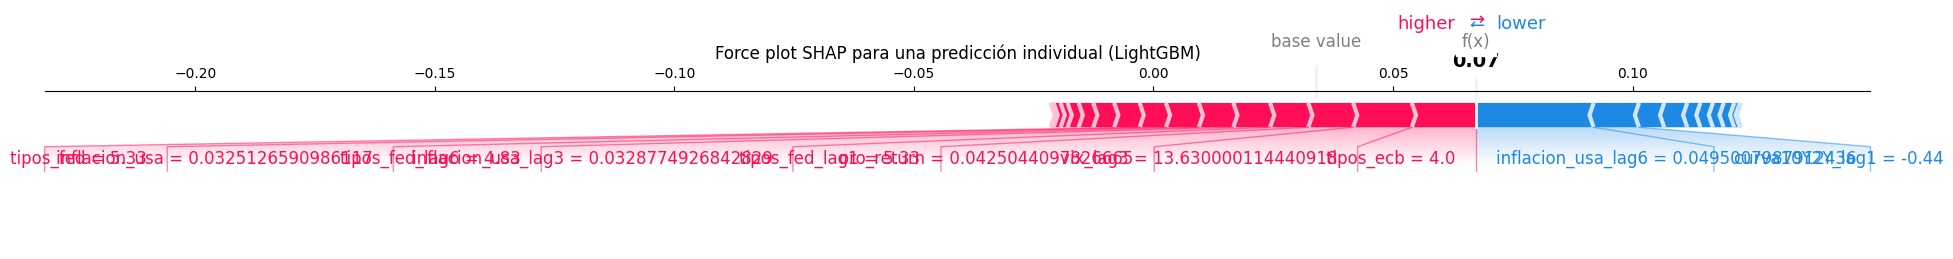

In [20]:
plt.figure(figsize=(14, 4))
shap.force_plot(expected_value_scalar_lgb, shap_values_for_plot_lgb, sample, 
                matplotlib=True, show=False)
plt.title(f"Force plot SHAP para una predicción individual (LightGBM)")
plt.tight_layout()
plt.show()

In [21]:
feature_names = X_train.columns.tolist()

# Crear el explainer LIME (tabular)
explainer_lime_lgb = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    mode='regression',  # Es un problema de regresión
    random_state=42,
    verbose=False
)

In [22]:
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]

print(f"Muestra seleccionada (índice {sample_idx}):")
print(f"Valor real: {y_test.iloc[sample_idx]:.4f}")
print(f"Predicción del modelo: {best_lgb.predict(sample)[0]:.4f}")

Muestra seleccionada (índice 0):
Valor real: 0.1123
Predicción del modelo: 0.0673


In [23]:
exp_lime_lgb = explainer_lime_lgb.explain_instance(
    data_row=sample.values[0],
    predict_fn=best_lgb.predict,
    num_features=10,  # Mostrar las 10 variables más importantes
    num_samples=5000
)

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [24]:
print("\n=== EXPLICACIÓN LIME PARA RANDOM FOREST ===")
print(exp_lime_lgb.as_list())



=== EXPLICACIÓN LIME PARA RANDOM FOREST ===
[('tipos_ecb > 1.00', 0.016846887740821173), ('13.42 < vix_lag3 <= 16.48', 0.013866260345280655), ('tipos_fed_lag6 > 2.02', 0.013797333974748192), ('curva10Y2Y_lag1 <= 0.47', -0.01129042852850559), ('inflacion_usa > 0.03', -0.009764543727275043), ('desempleo_lag3 <= 4.70', 0.009664391665575138), ('inflacion_usa_lag3 > 0.03', -0.009175798017175961), ('16.38 < vix_lag1 <= 22.16', -0.009075761981969842), ('curva10Y2Y_lag3 <= 0.47', 0.008896535519431892), ('0.06 < volatilidad_6m <= 0.08', 0.008592100782792276)]


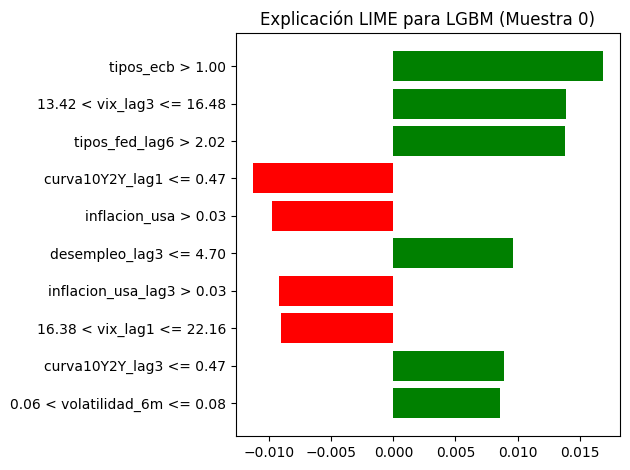

In [25]:
# La figura se guardará como 'lime_rf.png'
fig = exp_lime_lgb.as_pyplot_figure()
plt.title(f"Explicación LIME para LGBM (Muestra {sample_idx})")
plt.tight_layout()
plt.show()
